<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/Handling_missing_data_categorical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handling categorical missing data

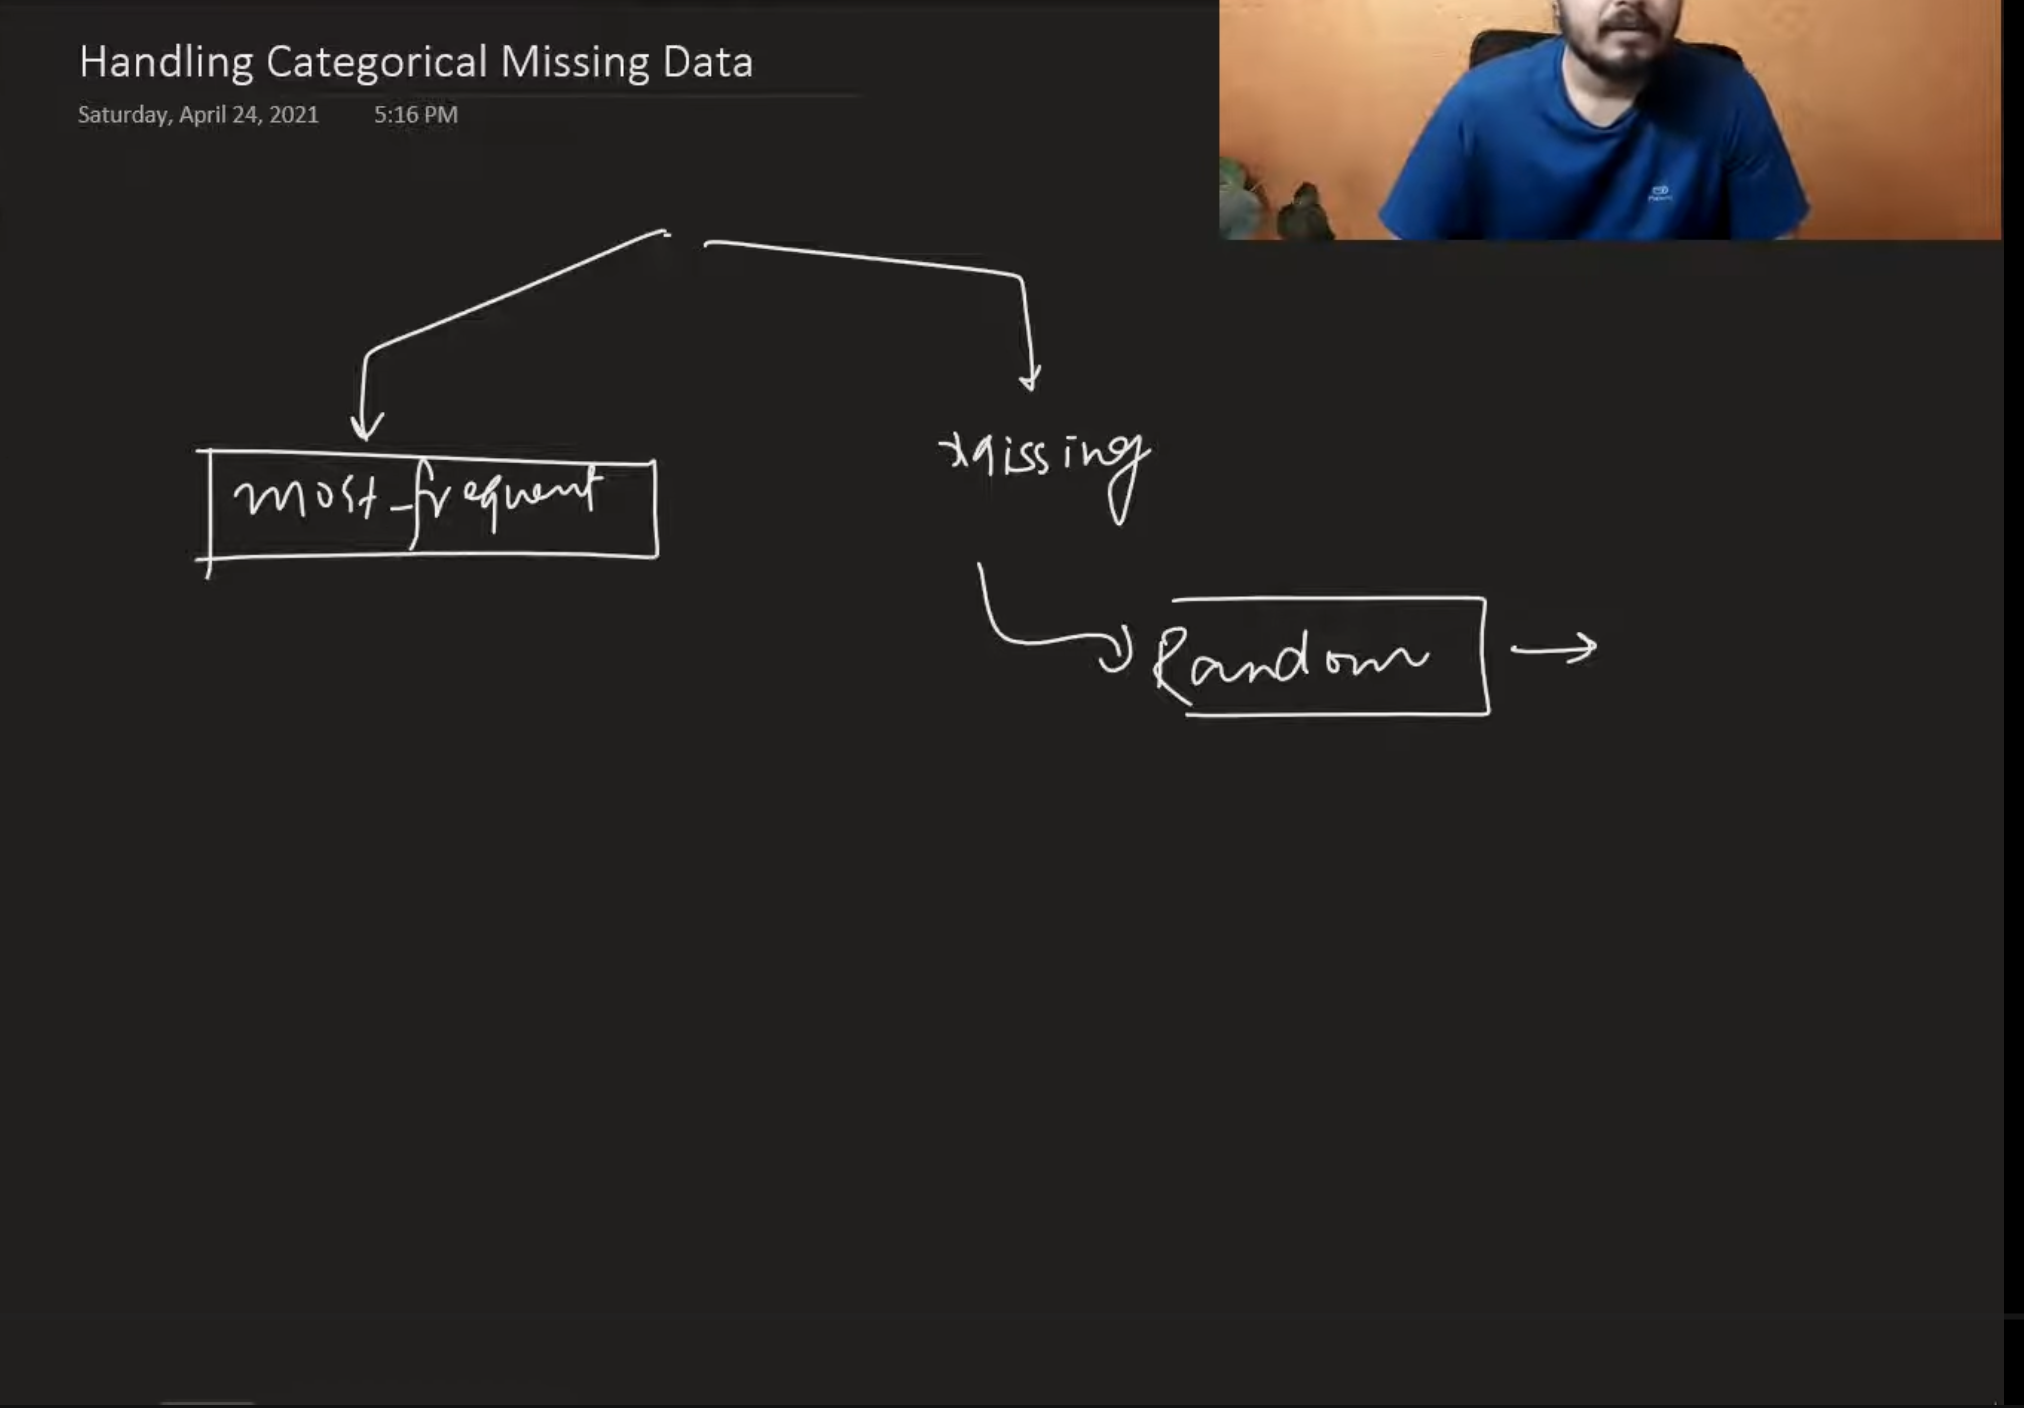

# Most Frequent Value Imputation

<5%

MCAR -> Mode (frequently data -> bahot zyaaaadaaaa)

Benifit : Easy

Downside : Change the distribution

# Missing Category Imputation
More than 10% missing
- change it to 'missing'

Benifit: Easy

Downside: Randomness

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day37-handling-missing-categorical-data/train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [28]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [29]:
df.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [30]:
df['GarageQual'].value_counts()

,count
GarageQual,
TA,1311
Fa,48
Gd,14
Ex,3
Po,3


<Axes: xlabel='GarageQual'>

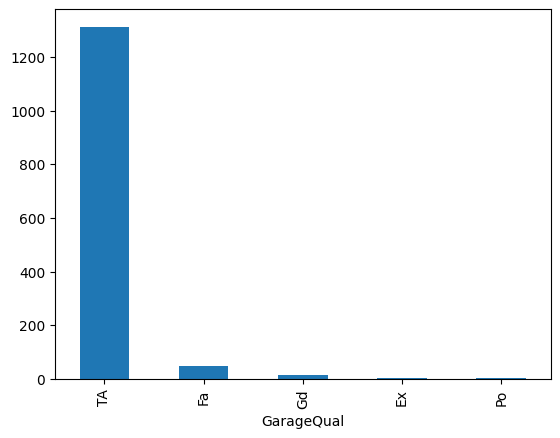

In [31]:
df['GarageQual'].value_counts().plot(kind='bar')

In [32]:
df['GarageQual'].mode()

,GarageQual
0,TA


Text(0.5, 1.0, 'GarageQual')

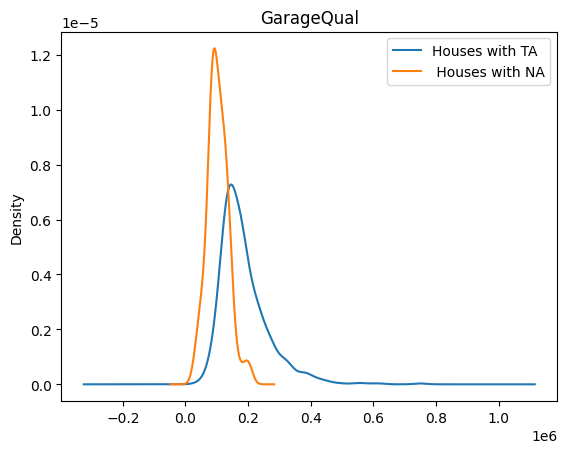

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax)

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA', ' Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')

In [34]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']

In [35]:
df['GarageQual'].fillna('TA', inplace=True)

/tmp/ipykernel_9452/1818999247.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA', inplace=True)


<Axes: xlabel='GarageQual'>

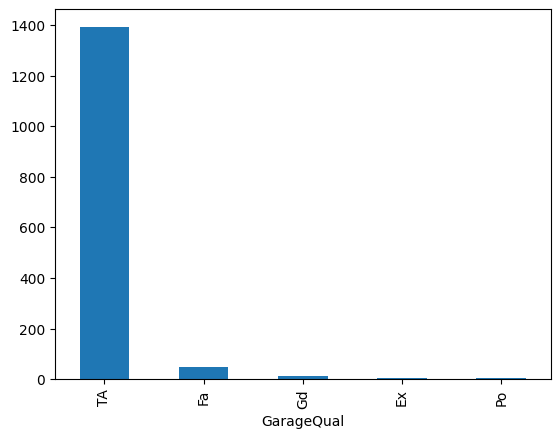

In [36]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

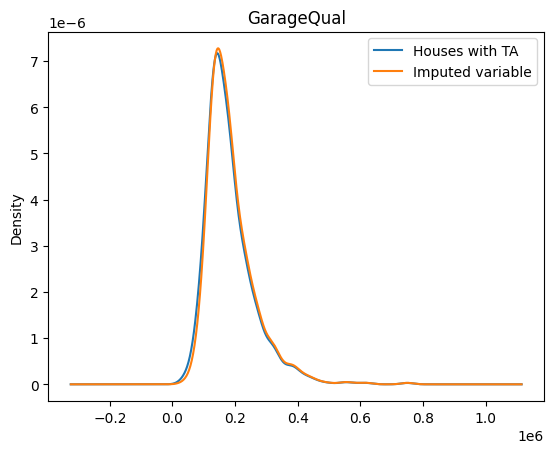

In [37]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax)
temp.plot(kind='kde', ax=ax)

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA', 'Imputed variable']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

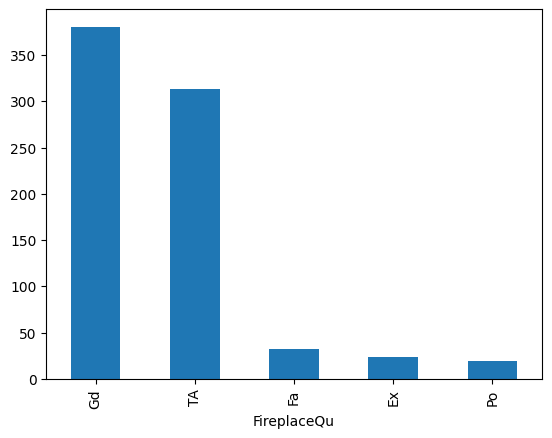

In [38]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [39]:
df['FireplaceQu'].mode()

,FireplaceQu
0,Gd


Text(0.5, 1.0, 'FireplaceQu')

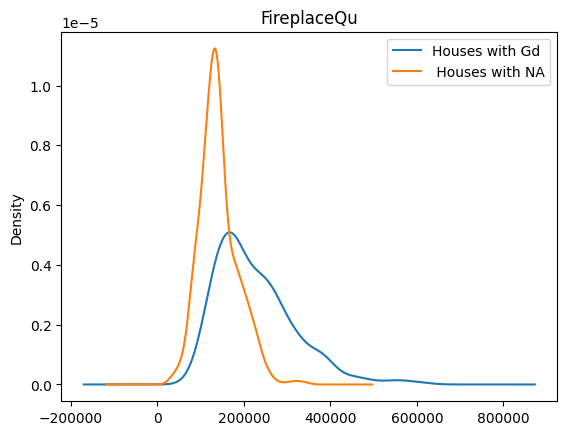

In [40]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax)

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', ' Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

In [41]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [42]:
df['FireplaceQu'].fillna('Gd', inplace=True)

/tmp/ipykernel_9452/3912738894.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd', inplace=True)


Text(0.5, 1.0, 'FireplaceQu')

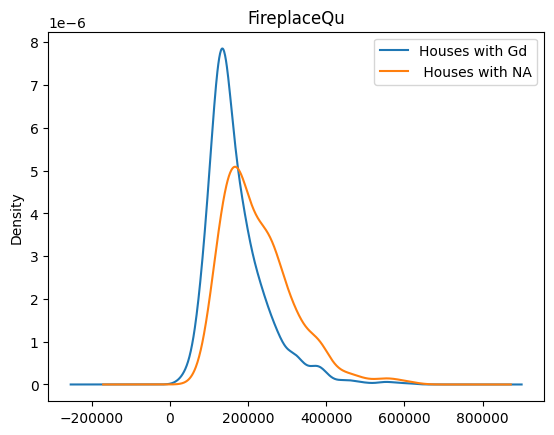

In [43]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax)
temp.plot(kind='kde', ax=ax)

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', ' Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

# Using Sklearn

In [46]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice' ]),df['SalePrice'],test_size=0.2)

In [47]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')

In [48]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [49]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

# same for missing_value